In [1]:
%autoreload 2

import numpy as np
import pandas as pd
import pickle as pkl
from glob import glob

from scipy.stats import ttest_ind, ttest_rel, sem, t

import matplotlib.pyplot as plt
import seaborn as sns

import sys
from glob import glob
from tqdm import tqdm
import seaborn as sns


import scipy.io as sio

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import fdrcorrection

sys.path.insert(0, '/mnt/hdd2/associative_learning/notebooks/toolbox/')
from fmri_toolbox import FMRIToolbox

# matlab and seaborn config
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
sns.set(style="whitegrid")
import matplotlib.lines as mlines
def add_significance(ax, x1, x2, y, h, text):
    if text=='ns': return
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5, color='black')
    ax.text((x1 + x2) * .5, y + h, text, ha='center', va='bottom', color='black', fontsize=20)


In [ ]:
filenames = sorted(glob('/mnt/hdd2/associative_learning/analysis/rt/*.pkl'))

In [3]:
logs = {}
for filename in filenames:
    with open(filename, 'rb') as f:
        data = pkl.load(f)
    logs[filename.split('/')[-1][24:30]] = data

In [5]:
results = []
for sub in logs.keys():
    results.append(np.array(logs[sub]['WhatOff'], dtype=np.float64))
    results.append(np.array(logs[sub]['WhatOn'], dtype=np.float64))

In [6]:

def barplot_annotate_brackets(num1, num2, data, center, height, yerr=None, dh=.05, barh=.02, fs=None, maxasterix=None):

    if data < 0.0001:
        text = '****'
    elif data < 0.001:
        text = '***'
    elif data < 0.01:
        text = '**'
    elif data < 0.05:
        text = '*'
    else:
        text = 'ns'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    # if yerr:
    #     ly += yerr[num1]/2
    #     ry += yerr[num2]/2

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    plt.plot(barx, bary, c='black', alpha=0.5)

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    plt.text(*mid, text, **kwargs)

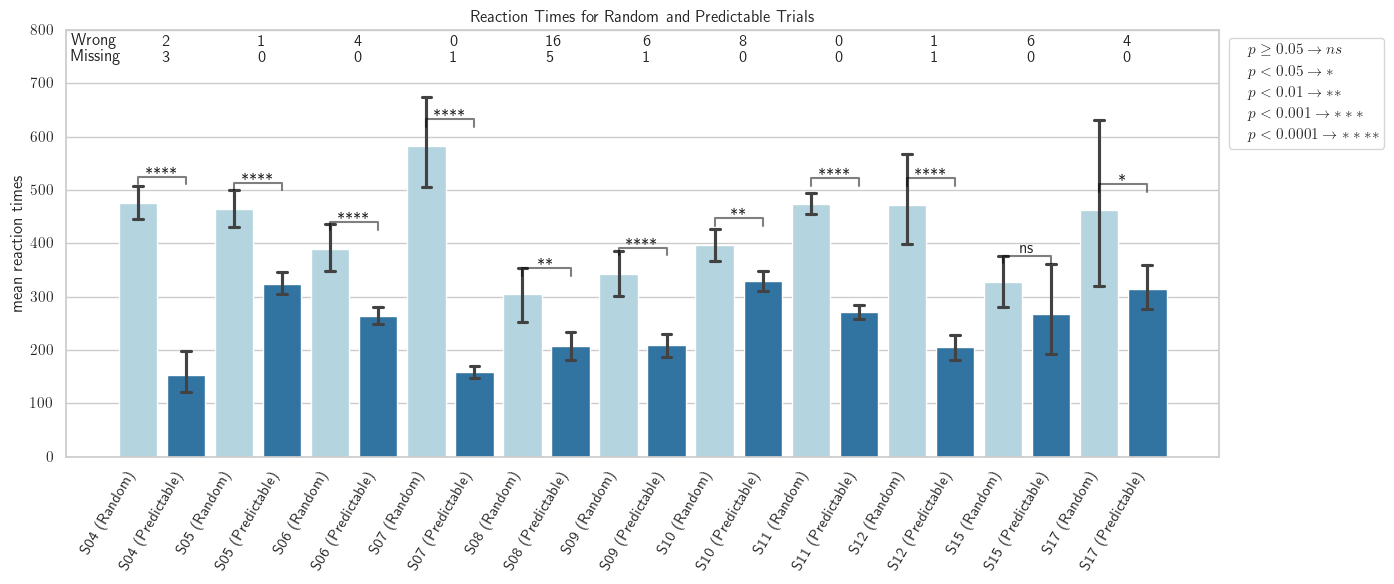

In [7]:
fig, ax = plt.subplots(figsize=[14, 6])

colors = ["#ADD8E6", "#1F77B4"] * 11

ax = sns.barplot(results, palette=colors, capsize=.2, capstyle='butt')

plt.xticks(range(22), ['S04 (Random)', 'S04 (Predictable)',
                       'S05 (Random)', 'S05 (Predictable)',
                       'S06 (Random)', 'S06 (Predictable)',
                       'S07 (Random)', 'S07 (Predictable)',
                       'S08 (Random)', 'S08 (Predictable)',
                       'S09 (Random)', 'S09 (Predictable)',
                       'S10 (Random)', 'S10 (Predictable)',
                       'S11 (Random)', 'S11 (Predictable)',
                       'S12 (Random)', 'S12 (Predictable)',
                       'S15 (Random)', 'S15 (Predictable)',
                       'S17 (Random)', 'S17 (Predictable)'])

heights_mean = [np.mean(res) for res in results]
heights_std = [np.std(res) for res in results]

for i in range(22)[::2]:
    p = ttest_ind(results[i],results[i+1]).pvalue
    tstat = ttest_ind(results[i],results[i+1]).statistic
    
    # print(f'{p:0.4f}, {tstat:0.4f}')
    barplot_annotate_brackets(i, i+1, p, range(len(results)), heights_mean)#, yerr=ci[1].tolist())
    
    plt.text(i+0.5, 770, f'{len(list(logs.values())[i//2]["WrongChoice"])}%')
    plt.text(i+0.5, 740, f'{len(list(logs.values())[i//2]["NoChoice"])}%')
plt.text(-1.4, 770, 'Wrong')
plt.text(-1.4, 740, 'Missing')
    
plt.xticks(rotation=60, ha='right')
plt.legend(
    [r'$p\geq0.05 \rightarrow ns$',
     r'$p< 0.05\rightarrow *$',
     r'$p< 0.01\rightarrow **$',
     r'$p< 0.001\rightarrow ***$',
     r'$p< 0.0001\rightarrow ****$',
    ],
    handlelength=0,
    loc='upper right', bbox_to_anchor=(1.15, 1))

plt.ylim([0,800])
plt.ylabel('mean reaction times')
plt.title('Reaction Times for Random and Predictable Trials')
plt.tight_layout()
plt.savefig('behavioral_results.png')
plt.show()



### Wrong Choices

In [8]:
wrong = [len(logs[sub]['WrongChoice']) for sub in logs.keys()]
print(f'{np.mean(wrong):0.4f}, {np.std(wrong):0.4f}')

4.3636, 4.4777


### Missing Choices

In [9]:
missing = [len(logs[sub]['NoChoice']) for sub in logs.keys()]
print(f'{np.mean(missing)}, {np.std(missing):0.4f}')

1.0, 1.5374


In [10]:
len(logs['sub_04']['WhatOff']) + len(logs['sub_04']['WhatOn']) +  len(logs['sub_04']['WrongChoice']) + len(logs['sub_04']['NoChoice'])

100

In [88]:
# quantify
lgs = {}

for sid in ['04', '05', '06', '07', '08', '09', '10', '11', '12', '15', '17']:
    lgs[sid] = []
    for fn in sorted(glob(f'/home/mahdi/hdd2/associative_learning/all_behavioral/reaction_times_Training_sub_{sid}_run_*.pkl')):
        with open(fn, 'rb') as f:
            data = pkl.load(f)
            lgs[sid].append(data)

In [97]:
accs = []
confs = []
nores = []
for sid in ['04', '05', '06', '07', '08', '09', '10', '11', '12', '15', '17']:
    n_errors = sum([len(lgs[sid][idx]['WrongChoice']) + len(lgs[sid][idx]['NoChoice']) for idx in range(len(lgs[sid]))])
    n_trials = sum([len(lgs[sid][idx]['WhatOn']) + len(lgs[sid][idx]['WhatOff']) + len(lgs[sid][idx]['WrongChoice']) + len(lgs[sid][idx]['NoChoice']) for idx in range(len(lgs[sid]))])
    accs.append(100-n_errors/n_trials)
    # print(n_errors, n_trials, n_errors/n_trials)
    confs.append(sum([len(lgs[sid][idx]['WrongChoice']) for idx in range(len(lgs[sid]))]))
    nores.append(sum([len(lgs[sid][idx]['NoChoice']) for idx in range(len(lgs[sid]))]))

np.mean(accs), np.std(accs)

(99.95647107438016, 0.03507034744855258)

In [103]:
mean_WhatOn = []
mean_WhatOff = []

for sub in logs.keys():
    mean_WhatOn.append(np.mean(logs[sub]['WhatOn'], dtype=np.float64))
    mean_WhatOff.append(np.mean(logs[sub]['WhatOff'], dtype=np.float64))

In [104]:
ttest_rel(mean_WhatOn, mean_WhatOff).pvalue
print(ttest_rel(mean_WhatOn, mean_WhatOff))


sys.path.insert(0, '/mnt/hdd2/associative_learning/notebooks/toolbox/')
from fmri_toolbox import FMRIToolbox
data_dir = f'/mnt/hdd2/associative_learning/analysis/estimates/single_trial_gm_mask'
mask_dir = '/mnt/hdd2/associative_learning/masks/drawn_regions/'
tbx = FMRIToolbox(data_dir, mask_dir=mask_dir)

TtestResult(statistic=-5.248219117208846, pvalue=0.0003743450161892832, df=10)


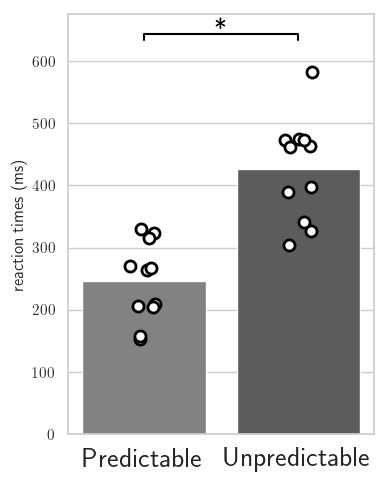

In [105]:
fig, ax = plt.subplots(figsize=[4, 5])
palette = sns.color_palette('Greys')

colors = [palette[-3], palette[-2]]

ax = sns.barplot([mean_WhatOn, mean_WhatOff], palette=colors, errorbar=None) #, capsize=.2, capstyle='butt', linewidth=2)
sns.stripplot([mean_WhatOn, mean_WhatOff], jitter=True, color='white', size=8, marker='o', edgecolor='black', linewidth=2, ax=ax, alpha=1)
add_significance(ax, 0, 1, np.max([mean_WhatOn, mean_WhatOff])+50, 10, '*') #tbx.viz.pvals2stars(ttest_rel(mean_WhatOn, mean_WhatOff).pvalue))

plt.xticks(range(2), ['Predictable', 'Unpredictable'])
plt.xticks(rotation=0, ha='center', fontsize=20)
ax.set_ylabel('reaction times (ms)')
plt.tight_layout()
plt.savefig('./results/behavioral_reaction_times.png', dpi=300, bbox_inches='tight')
plt.show()


In [106]:
# collect run1 results

logs_run1 = {}
for filename in sorted(glob('/mnt/hdd2/associative_learning/analysis/rt/run1/*')):
    with open(filename, 'rb') as f:
        data = pkl.load(f)
    logs_run1[filename.split('/')[-1][24:30]] = data

mean_WhatOn_run1 = []
mean_WhatOff_run1 = []

for sub in logs_run1.keys():
    mean_WhatOn_run1.append(np.mean(logs_run1[sub]['WhatOn'], dtype=np.float64))
    mean_WhatOff_run1.append(np.mean(logs_run1[sub]['WhatOff'], dtype=np.float64))

In [107]:
ttest_rel(mean_WhatOn_run1, mean_WhatOff_run1).pvalue
print(ttest_rel(mean_WhatOn_run1, mean_WhatOff_run1))

sys.path.insert(0, '/mnt/hdd2/associative_learning/notebooks/toolbox/')
from fmri_toolbox import FMRIToolbox
data_dir = f'/mnt/hdd2/associative_learning/analysis/estimates/single_trial_gm_mask'
mask_dir = '/mnt/hdd2/associative_learning/masks/drawn_regions/'
tbx = FMRIToolbox(data_dir, mask_dir=mask_dir)

TtestResult(statistic=-2.7954146336312835, pvalue=0.01894297882713815, df=10)


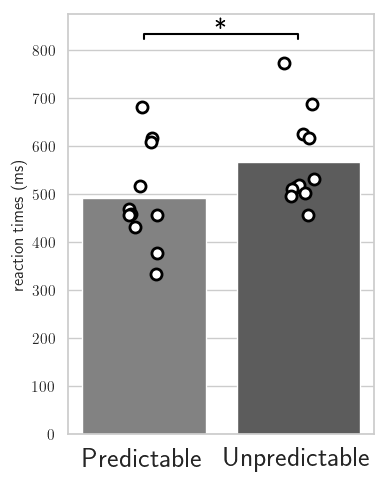

In [108]:
fig, ax = plt.subplots(figsize=[4, 5])
palette = sns.color_palette('Greys')

colors = [palette[-3], palette[-2]]

ax = sns.barplot([mean_WhatOn_run1, mean_WhatOff_run1], palette=colors, errorbar=None) #, capsize=.2, capstyle='butt', linewidth=2)
sns.stripplot([mean_WhatOn_run1, mean_WhatOff_run1], jitter=True, color='white', size=8, marker='o', edgecolor='black', linewidth=2, ax=ax, alpha=1)
add_significance(ax, 0, 1, np.max([mean_WhatOn_run1, mean_WhatOff_run1])+50, 10, '*') #tbx.viz.pvals2stars(ttest_rel(mean_WhatOn_run1, mean_WhatOff_run1).pvalue))

plt.xticks(range(2), ['Predictable', 'Unpredictable'])
plt.xticks(rotation=0, ha='center', fontsize=20)
ax.set_ylabel('reaction times (ms)')
plt.tight_layout()
# plt.savefig('./results/behavioral_reaction_times.png', dpi=300, bbox_inches='tight')
plt.show()


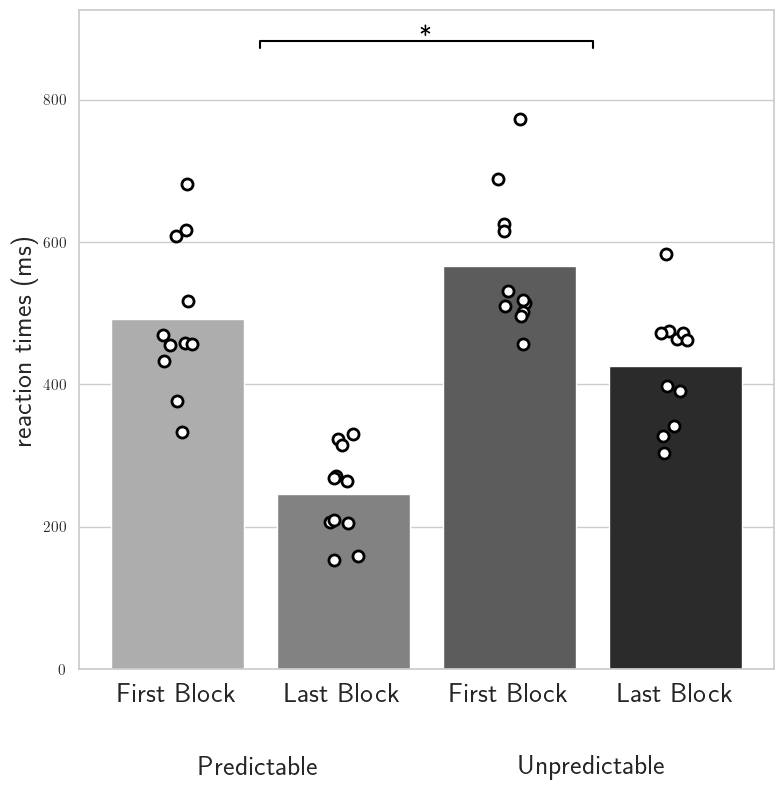

In [110]:
# test

fig, ax = plt.subplots(figsize=[8, 8])
palette = sns.color_palette('Greys')

colors = [palette[-4], palette[-3], palette[-2], palette[-1]]

ax = sns.barplot([mean_WhatOn_run1, mean_WhatOn, mean_WhatOff_run1, mean_WhatOff], palette=colors, errorbar=None) #, capsize=.2, capstyle='butt', linewidth=2)
sns.stripplot([mean_WhatOn_run1, mean_WhatOn, mean_WhatOff_run1, mean_WhatOff], jitter=True, color='white', size=8, marker='o', edgecolor='black', linewidth=2, ax=ax, alpha=1)
# add_significance(ax, 0, 1, np.max([mean_WhatOn_run1, mean_WhatOff_run1])+50, 10, '*')
# add_significance(ax, 2, 3, np.max([mean_WhatOn_run1, mean_WhatOff_run1])+50, 10, '*')
add_significance(ax, .5, 2.5, np.max([mean_WhatOn_run1, mean_WhatOff_run1])+100, 10, '*')

# plt.subplots_adjust(bottom=0.2, top=1.2)
ax.annotate('Predictable', xy=(0.28-.02, -0.15), xycoords='axes fraction', ha='center', va='center', fontsize=20, fontweight='bold')
ax.annotate('Unpredictable', xy=(0.76-.02, -0.15), xycoords='axes fraction', ha='center', va='center', fontsize=20, fontweight='bold')

plt.xticks(range(4), ['First Block', 'Last Block', 'First Block', 'Last Block'])
plt.xticks(rotation=0, ha='center', fontweight='bold', fontsize=20)
ax.set_ylabel('reaction times (ms)', fontweight='bold', fontsize=20)
plt.tight_layout()
plt.savefig('./results/behavioral_reaction_times_bars.png', dpi=300, bbox_inches='tight')
plt.show()


<Axes: >

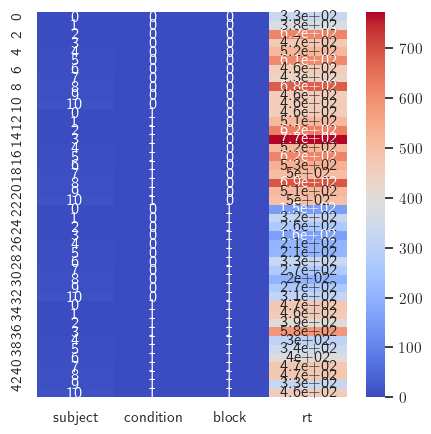

In [19]:
rt = np.concatenate([mean_WhatOn_run1, mean_WhatOff_run1, mean_WhatOn, mean_WhatOff])
subject = np.concatenate([np.arange(11)]*4)
condition = np.concatenate([np.zeros(11), np.ones(11)]*2)
block = np.concatenate([np.zeros(22), np.ones(22)])

data = np.stack([subject, condition, block, rt])

df = pd.DataFrame(data.T, columns=['subject', 'condition', 'block', 'rt'])

plt.figure(figsize=(5, 5))
sns.heatmap(df, annot=True, cmap='coolwarm')

In [41]:
import pingouin as pg
import pandas as pd

aov = pg.rm_anova(
    dv='rt',
    within=['condition', 'block'],
    subject='subject',
    data=df,
    detailed=True
)
display(aov)

,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,condition,179910.248101,1,10,179910.248101,20.457200,0.001103,0.001103,0.363930,1.0
1,block,409766.188510,1,10,409766.188510,34.239634,0.000161,0.000161,0.565811,1.0
2,condition * block,30612.623692,1,10,30612.623692,18.062852,0.001689,0.001689,0.088718,1.0


In [26]:
latex_table = aov.to_latex(index=False)
print(latex_table)

\begin{tabular}{lrrrrrrrrr}
\toprule
Source & SS & ddof1 & ddof2 & MS & F & p-unc & p-GG-corr & ng2 & eps \\
\midrule
condition & 179910.248101 & 1 & 10 & 179910.248101 & 20.457200 & 0.001103 & 0.001103 & 0.363930 & 1.000000 \\
block & 409766.188510 & 1 & 10 & 409766.188510 & 34.239634 & 0.000161 & 0.000161 & 0.565811 & 1.000000 \\
condition * block & 30612.623692 & 1 & 10 & 30612.623692 & 18.062852 & 0.001689 & 0.001689 & 0.088718 & 1.000000 \\
\bottomrule
\end{tabular}



In [27]:
aov_latex = aov.rename(columns={
    'Source': 'Effect',
    'ddof1': 'DF1',
    'ddof2': 'DF2',
    'F': 'F',
    'p-unc': 'p',
    'np2': r'$\eta_p^2$'
})

# Round for readability
aov_latex = aov_latex.round(5)

latex_table = aov_latex.to_latex(
    index=False,
    escape=False,       # allow math (η²)
    caption="Repeated-measures ANOVA results",
    label="tab:anova"
)

print(latex_table)

\begin{table}
\caption{Repeated-measures ANOVA results}
\label{tab:anova}
\begin{tabular}{lrrrrrrrrr}
\toprule
Effect & SS & DF1 & DF2 & MS & F & p & p-GG-corr & ng2 & eps \\
\midrule
condition & 179910.248100 & 1 & 10 & 179910.248100 & 20.457200 & 0.001100 & 0.001100 & 0.363930 & 1.000000 \\
block & 409766.188510 & 1 & 10 & 409766.188510 & 34.239630 & 0.000160 & 0.000160 & 0.565810 & 1.000000 \\
condition * block & 30612.623690 & 1 & 10 & 30612.623690 & 18.062850 & 0.001690 & 0.001690 & 0.088720 & 1.000000 \\
\bottomrule
\end{tabular}
\end{table}



In [39]:
pg.pairwise_tests(
    dv='rt',
    within='block',
    subject='subject',
    data=df[df['condition'] == 0],
    padjust='fdr_bh'
)

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,block,0.0,1.0,True,True,6.182205,10.0,two-sided,0.000104,278.42,2.706362


In [40]:
pg.pairwise_tests(
    dv='rt',
    within='block',
    subject='subject',
    data=df[df['condition'] == 1],
    padjust='fdr_bh'
)

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,block,0.0,1.0,True,True,4.665297,10.0,two-sided,0.000887,44.78,1.50007


# Viz Waveforms

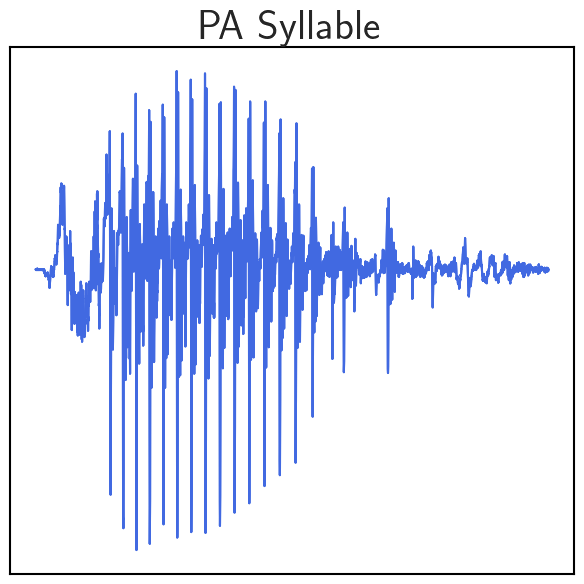

In [124]:

sample_rate, data = wavfile.read('/mnt/hdd2/associative_learning/experiment/LOG/S17_behavioral/assets/pa_70db.wav')
duration = len(data) / sample_rate
time = np.linspace(0., duration, len(data))
plt.figure(figsize=(6, 6), linewidth=2)
plt.plot(time, data, color='royalblue')
plt.title('PA Syllable', fontweight='bold', fontsize=30)
plt.xticks([])
plt.yticks([])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

for spine in plt.gca().spines.values():
    spine.set_visible(True)           # Make spine visible
    spine.set_color('black')          # Set border color to black
    spine.set_linewidth(1.5)        
    
plt.tight_layout()
plt.savefig('./results/pa_waveform.png', dpi=300, bbox_inches='tight')
plt.show()


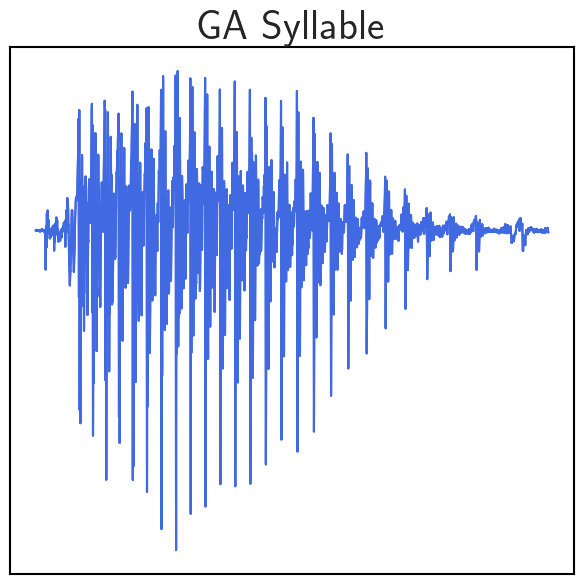

In [125]:

sample_rate, data = wavfile.read('/mnt/hdd2/associative_learning/experiment/LOG/S17_behavioral/assets/ga_70db.wav')
duration = len(data) / sample_rate
time = np.linspace(0., duration, len(data))
plt.figure(figsize=(6, 6), linewidth=2)
plt.plot(time, data, color='royalblue')
plt.title('GA Syllable', fontweight='bold', fontsize=30)
plt.xticks([])
plt.yticks([])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

for spine in plt.gca().spines.values():
    spine.set_visible(True)           # Make spine visible
    spine.set_color('black')          # Set border color to black
    spine.set_linewidth(1.5)        
    
plt.tight_layout()
plt.savefig('./results/ga_waveform.png', dpi=300, bbox_inches='tight')
plt.show()


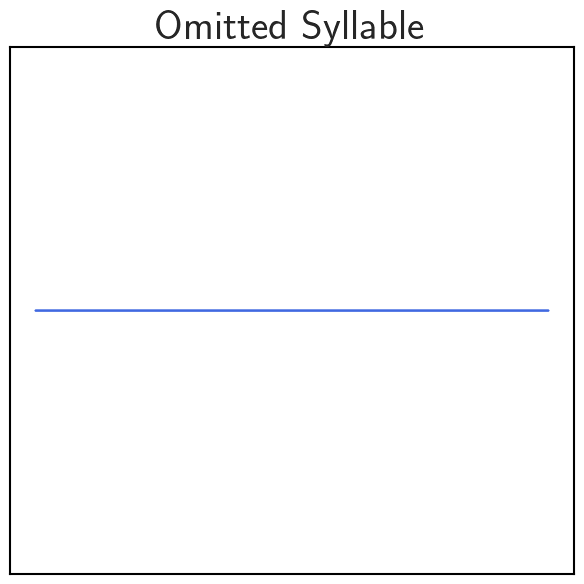

In [126]:

data = np.zeros_like(data)
duration = len(data) / sample_rate
time = np.linspace(0., duration, len(data))
plt.figure(figsize=(6, 6), linewidth=2)
plt.plot(time, data, color='royalblue')
plt.title('Omitted Syllable', fontweight='bold', fontsize=30)
plt.xticks([])
plt.yticks([])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

for spine in plt.gca().spines.values():
    spine.set_visible(True)           # Make spine visible
    spine.set_color('black')          # Set border color to black
    spine.set_linewidth(1.5)        
    
plt.tight_layout()
plt.savefig('./results/omitted_waveform.png', dpi=300, bbox_inches='tight')
plt.show()


---